In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Выжимка

Синусоиды разных частот в смысле скалярного произведения ортогональны друг другу. Поэтому преобразование Фурье выражает данные в новом ортогональном базисе. В видосе это объясняется https://www.youtube.com/watch?v=n2kesLcPY7o.  
Что сначала запутало мозги. Интеграл по `cos(x)` равен 0, но скалярка - это интеграл по `cos(x) * cos(x)`. И вот уже этот последний интеграл уже не равен 0 (т.е. скалярка базисной функции сама с собой).  
А вот интеграл `cos(x) * cos(y)` (где `x != y`, т.е. скалярка одной базисной функции с другой) равен 0.  
Если построить график скалярки, то по площади областей выше 0 и ниже 0 можно увидеть, что идёт компесация + на -, что в итоге даёт нулевую площадь => скалярка разных синусоид есть 0.

<img src="./img/cos-sum-prod-1.png">
<img src="./img/cos-sum-prod-2.jpg">

# Скалярное произведение базисной функции cos(x) с самой собой

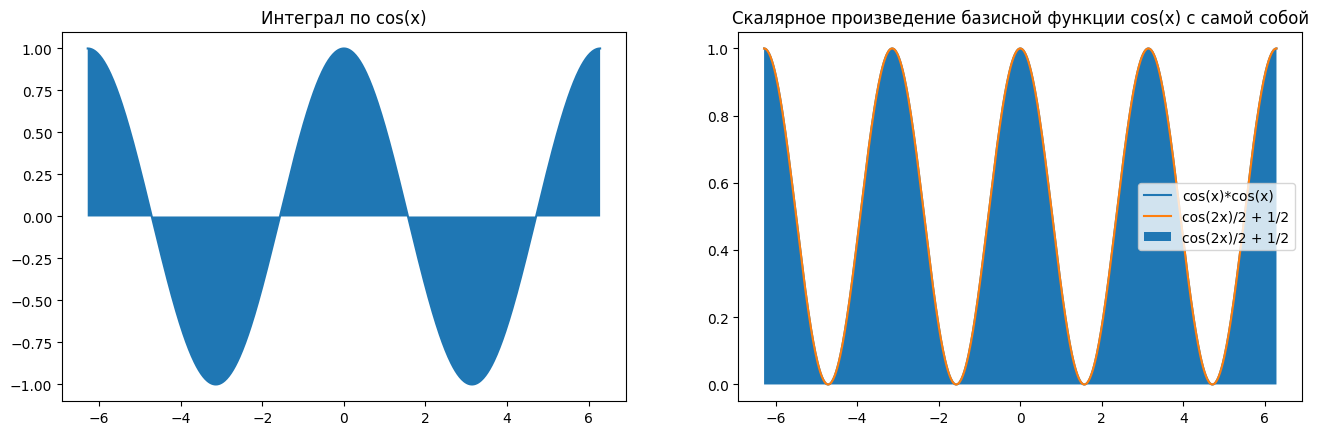

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)

ax1.set_title('Интеграл по cos(x)')
ax1.plot(x, np.cos(x), label='cos(x)')
ax1.fill_between(x, 0, np.cos(x))

ax2.set_title('Скалярное произведение базисной функции cos(x) с самой собой')
# ax2.plot(x, np.cos(x), label='cos(x)')
ax2.plot(x, np.cos(x) * np.cos(x), label='cos(x)*cos(x)')
ax2.plot(x, np.cos(2*x)/2 + 1/2, label='cos(2x)/2 + 1/2')
ax2.fill_between(x, 0, np.cos(2*x)/2 + 1/2, label='cos(2x)/2 + 1/2')
ax2.legend();

Визуально видно, что интеграл базисной функции равен 0 (площадь областей ниже 0 равна площади областей выше 0). При этом скалярное произведение базисной функции с самой собой > 0, т.к. график `cos(x)*cos(x)` всегда >= 0. 

# Скалярное произведение базисной функции cos(x) с базисной функцией cos(2x)

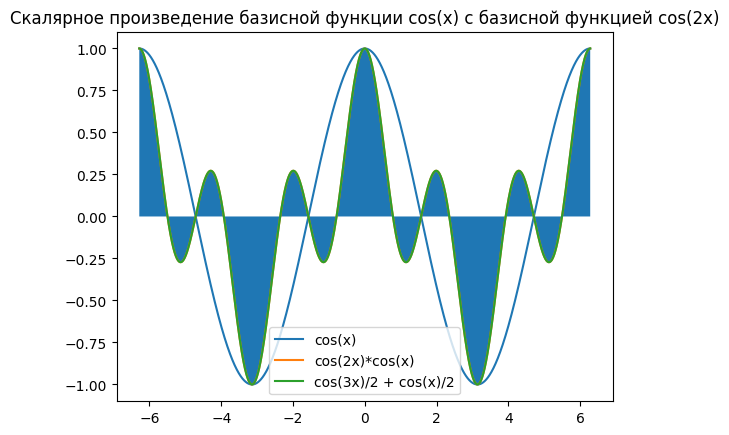

In [94]:
plt.title('Скалярное произведение базисной функции cos(x) с базисной функцией cos(2x)')
plt.plot(x, np.cos(x), label='cos(x)')
plt.plot(x, np.cos(2*x) * np.cos(x), label='cos(2x)*cos(x)')
plt.plot(x, np.cos(3*x)/2 + np.cos(x)/2, label='cos(3x)/2 + cos(x)/2')
plt.fill_between(x, 0, np.cos(2*x) * np.cos(x))
plt.legend();

In [97]:
np.cos(2*x) @ np.cos(x)

np.float64(0.9999999999998878)

Визуально видно, что интеграл произведения равен 0. Т.е. функции отрогональны. При этом `np.cos(2*x) @ np.cos(x)` > 0, что говорит о том, что так просто в лоб (дискретно+float) скалярку не посчитать для синусоид

# Три базисные функции

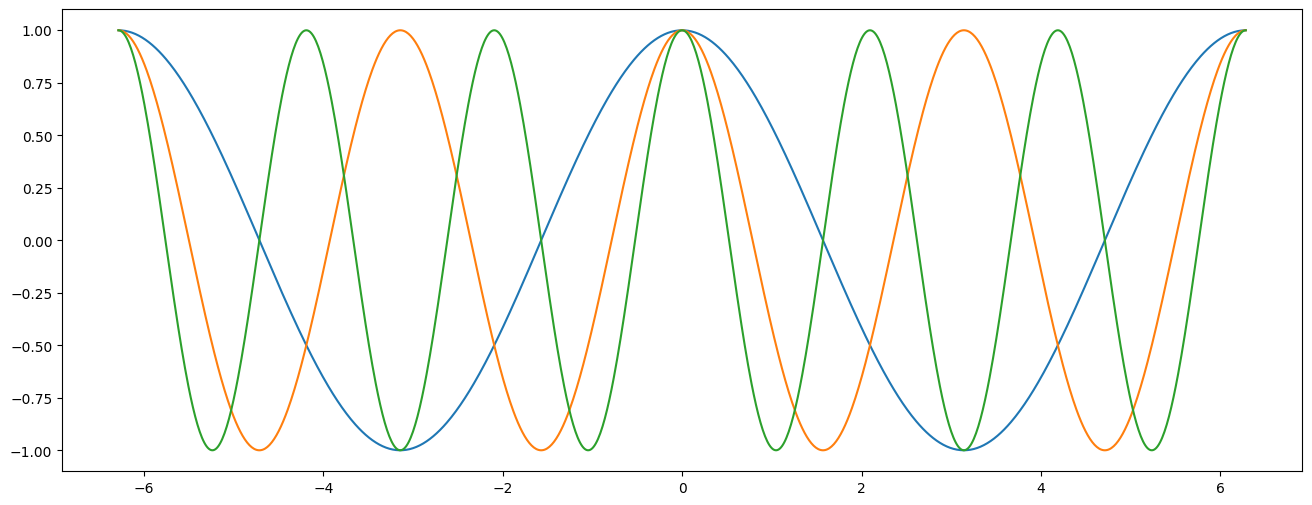

In [128]:
plt.figure(figsize=(16, 6))

x = np.linspace(-2*np.pi, 2*np.pi, 1000)
y1 = np.cos(1 * x)
y2 = np.cos(2 * x)
y3 = np.cos(3 * x)

# Equals to
# y1 = np.real(np.exp(1j*1*x))
# y2 = np.real(np.exp(1j*2*x))
# y3 = np.real(np.exp(1j*3*x))

plt.plot(x, y1);
plt.plot(x, y2);
plt.plot(x, y3);

In [126]:
y_mat = np.r_[[y1], [y2], [y3]]
pd.DataFrame(y_mat @ y_mat.T)

,0,1,2
0,500.5,1.0,1.0
1,1.0,500.5,1.0
2,1.0,1.0,500.5


Недиагональные элементы не равны 0 из-за округлений?